In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Phase 1: Data Understanding
df=pd.read_csv(r"F:\Desktop\python_dataset\AB_NYC_2019.csv")
df.shape
df.head()
df.tail()
df.info
# # Display Random Sample Records
df.sample(5)
# # Quick Summary Statistics
df.describe()
# df.describe(include="object")#For categorical summary

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [1]:
# Phase 2: Data Quality Assessment
# Missing Values
df.isnull().sum().sort_values(ascending=False)
# # # Duplicate Records
df.duplicated().sum()#--no duplicate
# Detect unrealistiv Values(Price, Nights)
# Zeroe Price Listings
(df["price"]==0).sum()
# Extremely High Prices
df["price"].describe()
# Look at high outliers:
df[df["price"]>1000].shape

#Availability Issues (Extreme or Unusual Patterns)
df["availability_365"].describe()
(df["availability_365"]==0).sum()


NameError: name 'df' is not defined

2.5 Summary of Data Quality Issues
Common issues in this dataset:
Missing values in last_review and reviews_per_month
Some listings have price = 0 (unrealistic)
Extreme pricing outliers (very high values)
Potential inconsistency: listings with reviews but missing last_review

In [5]:
# Phase 3 :Data Cleaning
# 3.1 Remove Duplicate Records
df=df.drop_duplicates()
# 3.2 Handle Missing Values
df["reviews_per_month"]=df["reviews_per_month"].fillna(0)
df["last_review"]=pd.to_datetime(df["last_review"],errors="coerce")
# optional feature:
df["has_review"]=np.where(df["last_review"].isnull(),0,1)

# 3.3 Remove Unrealistic Price Values
# Remove price = 0
df=df[df["price"]>0]

# 3.4 Treat Outliers in Price
upper_limit=df["price"].quantile(0.99)
df=df[df["price"]<=upper_limit]
print("Upper price linit used:",upper_limit)

# 3.5 Validate Cleaning
df.isnull().sum()
df.shape

Upper price linit used: 799.0


(48410, 17)

In [6]:
# Phase 4: Feature Preparation
# 4.1 Convert Categorical Variables (Where needed)
df["room_type"]=df["room_type"].astype("category")
df["neighbourhood_group"]=df["neighbourhood_group"].astype("category")
df["neighbourhood"]=df["neighbourhood"].astype("category")

# 4.2 Derived Features (Very Useful for EDA)
df["price_log"]=np.log1p(df["price"])
df["availability_category"]=pd.cut(
    df["availability_365"],
    bins=[-1,0,60,180,365],
    labels=["0 (Not Available)","1-60(Low)","61-180(Medium)","181-365(High)"]
)
df["review_activity"]=pd.cut(
    df["number_of_reviews"],
    bins=[-1,0,10,50,200,df["number_of_reviews"].max()],
    labels=["0","1-10","11-50","51-200","200+"]
)
df["min_nights_category"]=pd.cut(
    df["minimum_nights"],
    bins=[0,1,3,7,30,df["minimum_nights"].max()],
    labels=["1","2-3","4-7","8-30","30+"]
)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review,price_log,availability_category,review_activity,min_nights_category
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,...,9,2018-10-19,0.21,6,365,1,5.010635,181-365(High),1-10,1
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,...,45,2019-05-21,0.38,2,355,1,5.420535,181-365(High),11-50,1
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,...,0,NaT,0.00,1,365,0,5.017280,181-365(High),0,2-3
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,...,270,2019-07-05,4.64,1,194,1,4.499810,181-365(High),200+,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,...,9,2018-11-19,0.10,1,0,1,4.394449,0 (Not Available),1-10,8-30


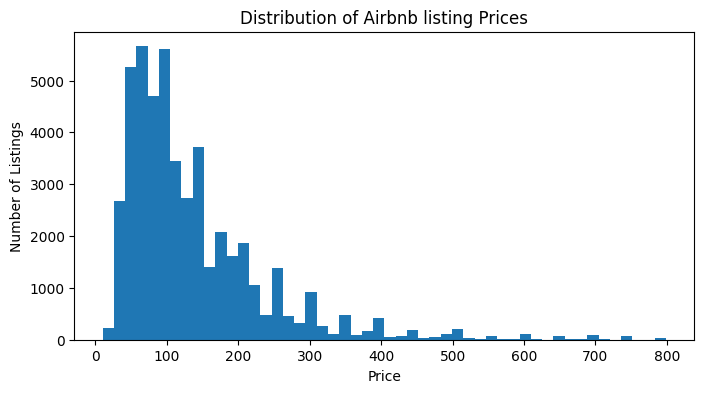

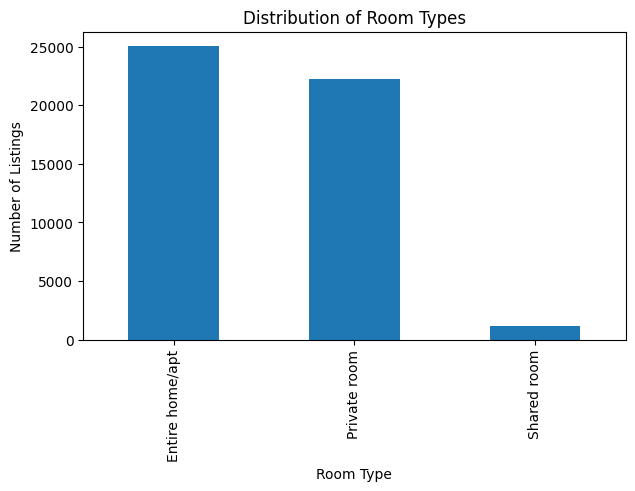

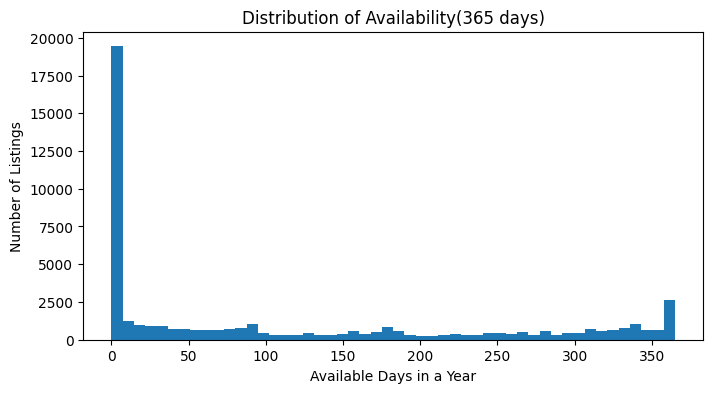

In [7]:
# Phase 5: Univariate Analysis
# 5.1 Distribution of Prices
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(df["price"],bins=50)
plt.title("Distribution of Airbnb listing Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()
# Observation (Markdown):
# Price distribution is highly right-skewed.
# Majority of listings are priced below a moderate range.
# Presence of high-price outliers even after cleaning.

# 5.2 Distribution of Room Types
df["room_type"].value_counts().plot(kind="bar",figsize=(7,4))
plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.show
# Observation:
# Entire home/apt and private rooms dominate the dataset.
# Shared rooms form a very small portion of listings.

# 5.3 Distribution of Availability (365 Days)
plt.figure(figsize=(8,4))
plt.hist(df["availability_365"],bins=50)
plt.title("Distribution of Availability(365 days)")
plt.xlabel("Available Days in a Year")
plt.ylabel("Number of Listings")
plt.show()
# Observation:
# Many listings have low or zero availability.
# Suggests a mix of full-time and part-time hosts.


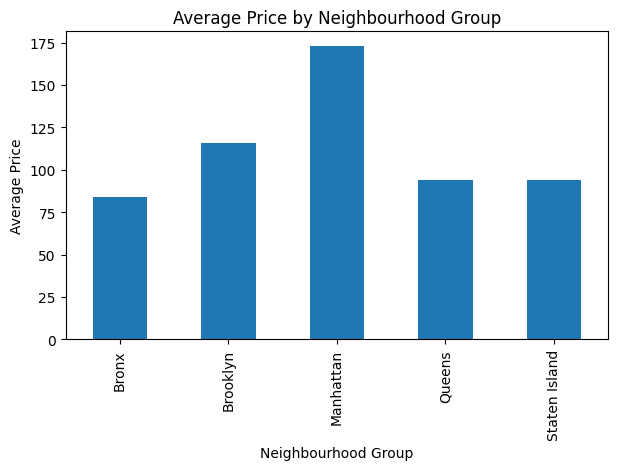

In [11]:
# Phase 6: Bivariate Analysis
# Study relationships between two variables to identify dependencies.
# 6.1 Price vs Neighbourhood Group
price_by_area=df.groupby("neighbourhood_group",observed=True)["price"].mean()
price_by_area.plot(kind="bar",figsize=(7,4))
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()

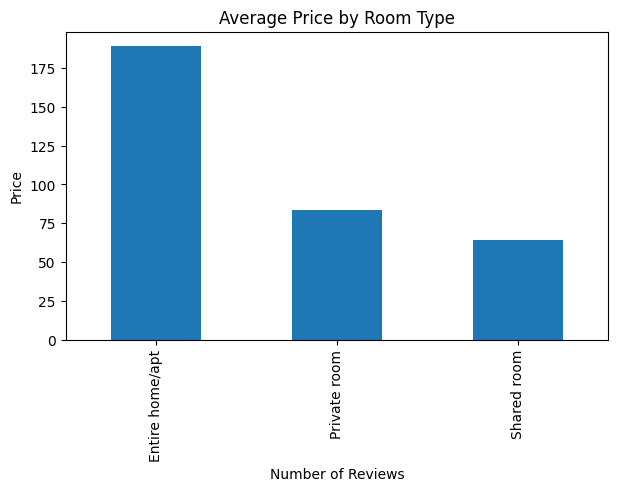

In [12]:
# 6.2 Price vs Room Type
price_by_room=df.groupby("room_type",observed=True)["price"].mean()
price_by_room.plot(kind="bar",figsize=(7,4))
plt.title("Average Price by Room Type")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

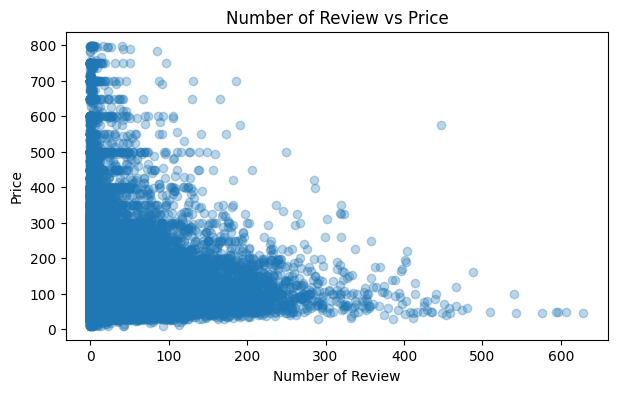

In [14]:
# 6.3 Number of Reviews vs Price
plt.figure(figsize=(7,4))
plt.scatter(df["number_of_reviews"],df["price"],alpha=0.3)
plt.title("Number of Review vs Price")
plt.xlabel("Number of Review")
plt.ylabel("Price")
plt.show()

In [ ]:
# 6.4 Availability vs Price
plt.figure(figsize=(7,4))
plt.scatter(df["availablility_365"],df["price"],alpha=0.3)
plt.title("Availability vs Price")
plt.xlabel("Availability(days)")
plt.ylabel("Price")
plt.show()

In [18]:
# Phase 7: Multivariate Analysis
# 7.1 Location + Room Type → Price
pivot_price=df.pivot_table(
    values="price",
    index="neighbourhood_group",
    columns="room_type",
    aggfunc="mean",
    observed=True
)
pivot_price

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,125.198413,63.147692,47.254237
Brooklyn,165.409283,72.127017,50.773723
Manhattan,216.958311,106.548424,84.085954
Queens,140.808816,67.757720,49.312821
Staten Island,131.087209,62.292553,57.444444


In [22]:
# 7.2 Availability Category + Room Type → Price
pivot_availability=df.pivot_table(
    values="price",
    index="availability_category",
    columns="room_type",
    aggfunc="mean",
    observed=True
)
pivot_availability

room_type,Entire home/apt,Private room,Shared room
availability_category,,,
0 (Not Available),170.828474,78.708478,73.481229
1-60(Low),175.262736,78.851014,66.621951
61-180(Medium),198.073343,86.635817,72.539535
181-365(High),214.008372,90.046197,53.958246


In [24]:
# 7.3 Review Activity + Location → Price
pivot_reviews=df.pivot_table(
    values="price",
    index="neighbourhood_group",
    columns="review_activity",
    aggfunc="mean"
)
pivot_reviews

C:\Users\shwet\AppData\Local\Temp\ipykernel_14048\2991797008.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_reviews=df.pivot_table(


review_activity,0,1-10,11-50,51-200,200+
neighbourhood_group,,,,,
Bronx,104.553991,79.182065,79.716049,77.201183,67.307692
Brooklyn,115.961773,113.660162,117.793217,119.375046,117.855019
Manhattan,199.059174,169.588741,164.098824,154.460123,128.588710
Queens,102.794824,95.438965,91.383871,87.400922,73.529412
Staten Island,118.654545,99.129310,85.033898,84.610390,67.000000


# Phase 8: Insight Development (10 data- supported Insights)
1. Manhattan has the highest average listing prices, reflecting premium demand and central location.

2. Entire home/apartment listings are consistently more expensive than private or shared rooms.

3. Brooklyn has a large number of listings with comparatively moderate pricing, making it a popular alternative.
4. Shared rooms are the least expensive option across all neighbourhoods.

5. Price distribution is highly skewed, indicating a small number of luxury listings.

6. Listings with high review counts are often competitively priced rather than premium priced.

7. Availability shows weak correlation with price, suggesting pricing depends more on location and room type.

8. Many listings have zero or very low availability, indicating part-time hosting behavior.

9. Private rooms in Manhattan are often priced higher than entire homes in outer boroughs.

10. Areas with high listing density indicate strong tourist demand and potential housing pressure.
(Each insight directly links to univariate, bivariate, or pivot-table analysis.)


# Phase 9:Final Conclusion
# Summary of findings
1. Airbnb pricing in NYC is primarily influenced by location and room type.
2. Manhattan dominates premium pricin, while Brooklyn offers a balance of demand and affordability
3. Entire homes command higher prices prices due to privacy and space. 
4. Review patterns suggest strategic pricing improves booking frequency.
<!-- For Hosts -->

1. Selecting the right neighbourhood and room type significantly impacts revenue.
2. Competitive pricing can increase reviews and occupancy.

<!-- For Guests -->
1. Budget travelers benefit from private/shared rooms in outer boroughs.
2. Entire homes outside Manhattan provide better value.

<!-- For City Planners -->

1. High listing concentration highlights tourism-pressure zones.
2. Data supports regulation and housing policy decisions.
<!-- 🔹 Limitations -->
1. Dataset is from 2019 and may not reflect current trends.
2. Availability does not guarantee actual bookings.
3. Outliers and missing values may still influence some results.
